# Forest Disturbance Detection with Multi-Kernel 1D U-Net
This notebook trains a 1D U-Net with multi-kernel convolutions to detect forest disturbance events in Landsat time series data.

## 1. Setup & Configuration

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split
import random
pd.set_option('display.float_format', '{:.2f}'.format)
np.set_printoptions(suppress=True)
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

import os
print(os.getcwd())

/home/ubuntu/work/saved_data/landsat_disturbance_detection/clean_1D_U_Net/deep_disturbance/Multikernel_Model


In [2]:
import torch
import numpy as np
import random
import os

def set_seed(seed=1):
    """
    Set seeds for reproducibility.
    
    Args:
        seed (int): Seed value to use. Default is 42.
    """
    # Set Python seed
    random.seed(seed)
    
    # Set NumPy seed
    np.random.seed(seed)
    
    # Set PyTorch seed
    torch.manual_seed(seed)
    
    # Set CUDA seed if available
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # for multi-GPU
        
        # Additional CUDA settings for reproducibility
        torch.backends.cudnn.deterministic = True
        
    # Set environment variable for additional reproducibility
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Random seed set to {seed}")

# Usage:
set_seed(42)  # or any other number you prefer

Random seed set to 42


## 2. Data Loading & Preprocessing

In [3]:
df = pd.read_csv('/home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/Data/Training/forest_dataset_timesync_alltiles_landsatbands_indices3_classes_ed5_calibration.csv',index_col=0, sep=';')
print(df.head())

# create disturbance labels
df['class'] = df['class_level1'].apply(lambda x: 1 if x == 'disturbance' else 0)
print(df.head(10))

import seaborn as sns
import matplotlib.pyplot as plt

# Plot distributions for each feature
features = ['GRN', 'RED', 'NIR', 'NBR', 'NDVI', 'TCB', 'TCG', 'TCW', 'SW1', 'SW2','DIn']

'''for feature in features:
    plt.figure(figsize=(3, 3))
    sns.kdeplot(df[df['new_class2_v5'] == 0][feature], label='Undisturbed', fill=True, color='blue')
    sns.kdeplot(df[df['new_class2_v5'] == 1][feature], label='Disturbed', fill=True, color='red')
    plt.title(f"{feature} Distribution by Class")
    plt.legend()
    plt.show()
'''


## filter doubtful samples
df = df[~((df['class_level1'] == 'treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'treed') & (df['NDVI'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NDVI'] < 0.5))]
df = df[~((['class_level1'] == 'disturbance') & (df['NBR'] > 0.5))]
df = df[~((['class_level1'] == 'disturbance') & (df['NDVI'] > 0.5))]

# Count the number of samples per class
class_counts = df['class_level1'].value_counts()
print(class_counts)


     country  plotid  year class_level1 class_level2  new_class2_v5  uniqueid  \
fid                                                                             
0    albania       1  1985        treed        treed              0  albania1   
1    albania       1  1986        treed        treed              0  albania1   
2    albania       1  1987        treed        treed              0  albania1   
3    albania       1  1988        treed        treed              0  albania1   
4    albania       1  1989        treed        treed              0  albania1   

     numerical_id        x           y      Tile_ID     merged_id    BLU  \
fid                                                                        
0               1 20660.18 -1493987.48  X0036_Y0032  1985albania1   5.00   
1               1 20660.18 -1493987.48  X0036_Y0032  1986albania1 293.00   
2               1 20660.18 -1493987.48  X0036_Y0032  1987albania1 161.00   
3               1 20660.18 -1493987.48  X0036_Y0032 

First numerical_id with class=1 is: 1


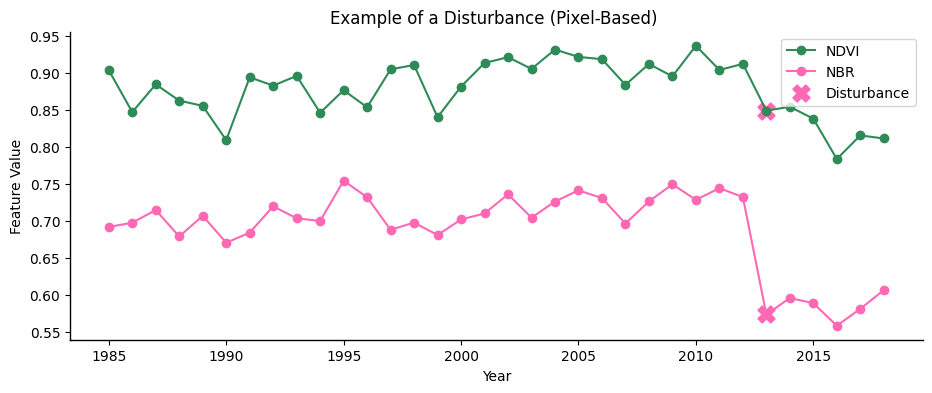

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

features = ['NDVI', 'NBR']

# Find first row where class == 1
first_idx = np.where(df['class'] == 1)[0][0]
first_num_id = df.loc[first_idx, 'numerical_id']
print(f"First numerical_id with class=1 is: {first_num_id}")

df_num_id = df[df['numerical_id'] == first_num_id]
#sns.set_theme(rc={'figure.figsize': (11, 4)})

# Set the style for clean white background
plt.style.use('default')  # Reset to default style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.alpha'] = 0  # Remove grid
plt.figure(figsize=(11, 4))
colors = ['seagreen', 'hotpink']

# Use actual years instead of index
years = df_num_id['year'].values  # Get the actual years

for i, feature in enumerate(features):
    plt.plot(years, df_num_id[feature], marker='o', linestyle='-', label=feature, color = colors[i])

# Find disturbance points and get their years
disturbance_rows = df_num_id.index[df_num_id['class'] == 1]
disturbance_years = df_num_id.loc[disturbance_rows, 'year'].values

for feature in features:
    plt.scatter(disturbance_years,  # Use years instead of row indices
                df_num_id.loc[disturbance_rows, feature],
                color='hotpink', s=150, marker='X',
                label='Disturbance' if feature == features[0] else "")

plt.xlabel('Year')  # Changed from 'Index or Time'
plt.ylabel('Feature Value')
plt.title(f'Example of a Disturbance (Pixel-Based) ')
plt.legend()
sns.despine()
plt.show()


In [5]:
import torch
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

# Check CUDA availability
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Current Device:", torch.cuda.current_device())
    print("Device Name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    torch.cuda.empty_cache()

CUDA Available: True
Current Device: 0
Device Name: NVIDIA GeForce RTX 3090


In [6]:


# Check CUDA availability
if not torch.cuda.is_available():
    print("CUDA is unavailable. Using CPU.")
    device = torch.device("cpu")
else:
    print("CUDA is available!")
    device = torch.device("cuda:0")
    torch.cuda.empty_cache()

# Test a small tensor on the GPU
try:
    x = torch.rand(3, 3).to(device)
    print("GPU Test Passed")
except RuntimeError as e:
    print(f"GPU Test Failed: {e}")

# Print GPU memory info
if torch.cuda.is_available():
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"Total GPU Memory: {gpu_props.total_memory / (1024**3):.2f} GB")
    print(f"Allocated Memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
    print(f"Cached Memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

CUDA is available!
GPU Test Passed
Total GPU Memory: 23.57 GB
Allocated Memory: 0.00 GB
Cached Memory: 0.00 GB


In [7]:
samples_data = []
samples_label = []

window_size = 8 # 16
missing = 0

for _, group in tqdm(df.groupby('uniqueid')):
    group = group.sort_values('year')
    if len(group) < 30:
        missing += 1
        continue
    #data = group[['NIR', 'SW1', 'SW2','NBR','NDVI','TCB','TCG','TCW','DIn']].diff().fillna(0)
    # Select the features you want to include (e.g., NBR, NDVI, TCW, SWIR) 
    features = ['RED', 'SW1', 'SW2', 'NBR', 'NDVI', 'TCG', 'TCW', 'DIn']           #### TRY ADDING ALSO NIT AND TCB!!!
    #features = ['BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2'] 

    data = group[features]
    
    # Prepare the data using these features
    #data = group[['NBR']].fillna(0)
    
    #data = group[features].interpolate(method='linear', limit_direction='both') 
    '''data = (
    group
    .groupby('uniqueid')[features]
    .apply(lambda g: g.interpolate(method='linear', limit_direction='both'))
    .reset_index(drop=True)
)   '''
    label = group['new_class2_v5'].to_numpy()

    # Apply a rolling window of size to the data with slicing
    data = np.array([data[i:i+window_size].to_numpy() for i in range(len(data)-window_size+1)])
    label = np.array([label[i:i+window_size] for i in range(len(label)-window_size+1)])

    #data = data.reshape((1,data.shape[0],data.shape[1]))
    #label = label.reshape((1,len(label)))

    samples_data.append(data)
    samples_label.append(label)

X = samples_data
y = samples_label
print("missing")
print(missing)

import numpy as np
flat_labels = np.concatenate(samples_label).flatten()
print("Class balance:", np.bincount(flat_labels.astype(int)))

  0%|          | 0/16954 [00:00<?, ?it/s]

100%|██████████| 16954/16954 [00:13<00:00, 1259.92it/s]

missing
2551
Class balance: [2961016    8984]


Plotting row 190
No disturbance found in row 190


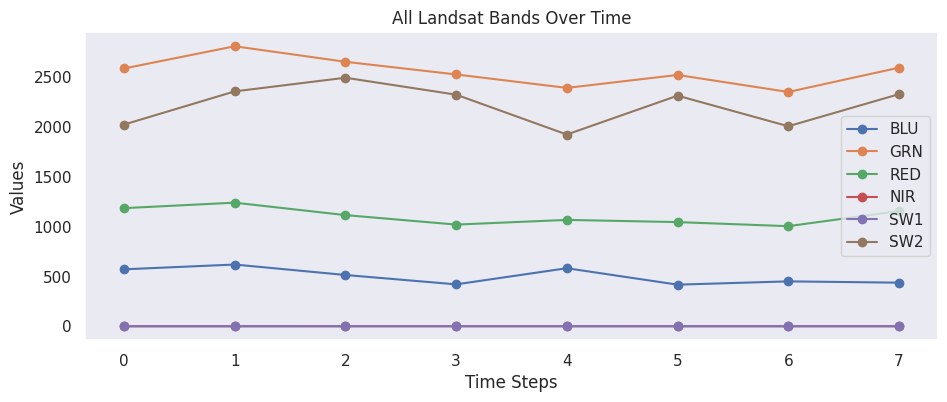

In [8]:
features = ['BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2']
sns.set_theme(rc={'figure.figsize': (11, 4)})

y_arr = np.concatenate(y, axis=0)  # shape (n_samples, window_size)

# Get the first row with any disturbance
row_idx = np.where((y_arr == 1).any(axis=1))[0][0]
print(f"Plotting row {row_idx}")

sample_X = X[row_idx][0]  # (window_size, num_features)
sample_y = y[row_idx][0]  # (window_size,)

# 1. Plot all features first
for i, feature_name in enumerate(features):
    plt.plot(sample_X[:, i], marker='o', linestyle='-', label=feature_name)

# 2. Mark disturbances on top
disturbance_steps = np.where(sample_y == 1)[0]
if disturbance_steps.size > 0:
    for i in range(len(features)):
        plt.scatter(disturbance_steps,
                    sample_X[disturbance_steps, i],
                    marker='x', color='red', s=100,
                    label='Disturbance' if i == 0 else "")
else:
    print(f"No disturbance found in row {row_idx}")

plt.legend()
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.title('All Landsat Bands Over Time')
plt.show()


### Stratify and Train-Test Split

In [9]:
# Label each time window based on presence of any disturbance in the sequence
stratify_labels = [1 if np.any(np.array(label) == 1) else 0 for label in y]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0, stratify=stratify_labels)


'''these arrays have different shapes'''
# Flatten the first dimension
X_train_new = np.concatenate(X_train, axis=0)
X_test_new = np.concatenate(X_test, axis=0)
y_train_new = np.concatenate(y_train, axis=0)
y_test_new = np.concatenate(y_test, axis=0)

In [10]:
# Compute class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
y_train_flat = y_train_new.flatten().astype(int)
weights = compute_class_weight('balanced', classes=classes, y=y_train_flat)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"Class weights: {class_weights}")

Class weights: tensor([  0.5015, 164.8449], device='cuda:0')


In [11]:
# Shuffle the data
def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

X_train_new, y_train_new = unison_shuffled_copies(X_train_new, y_train_new)
X_test_new, y_test_new = unison_shuffled_copies(X_test_new, y_test_new)

In [12]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import joblib

# Convert to numpy arrays
X_train = np.array(X_train_new, dtype=np.float32)
X_test = np.array(X_test_new, dtype=np.float32)

print(f"Before processing - X_train has NaN: {np.isnan(X_train).any()}")
print(f"Before processing - X_train NaN percentage: {np.isnan(X_train).mean() * 100:.1f}%")



'''scaler = MinMaxScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

# Fit scaler
scaler.fit(X_train_2d)

X_train_2d = scaler.transform(X_train_2d)
X_test_2d = scaler.transform(X_test_2d)

X_train_2d = X_train_2d.reshape(X_train.shape)
X_test_2d = X_test_2d.reshape(X_test.shape)'''




# STEP 1: Clean the data first
def clean_data_for_scaling(X):
    # Reshape to 2D
    X_2d = X.reshape(-1, X.shape[-1])
    
    # Replace NaN with a temporary sentinel value
    X_2d = np.nan_to_num(X_2d, nan=-9999, posinf=-9999, neginf=-9999)
    
    # Create mask for valid data (not the sentinel value)
    valid_mask = X_2d != -9999
    valid_rows = np.any(valid_mask, axis=1)
    
    print(f"Valid rows for scaling: {valid_rows.sum()} / {len(valid_rows)} ({valid_rows.mean()*100:.1f}%)")
    
    return X_2d, valid_rows

# Clean both datasets
X_train_2d, train_valid_rows = clean_data_for_scaling(X_train)
X_test_2d, test_valid_rows = clean_data_for_scaling(X_test)

# STEP 2: Fit scaler only on valid data
scaler = MinMaxScaler()

if train_valid_rows.sum() > 0:
    # Extract only valid training data for fitting
    valid_train_data = X_train_2d[train_valid_rows]
    print(f"Valid training data shape for scaler: {valid_train_data.shape}")
    print(f"Valid training data range: [{valid_train_data.min():.3f}, {valid_train_data.max():.3f}]")
    
    # Fit scaler
    scaler.fit(valid_train_data)
    
    # Transform valid data
    X_train_2d[train_valid_rows] = scaler.transform(X_train_2d[train_valid_rows])
    
    if test_valid_rows.sum() > 0:
        X_test_2d[test_valid_rows] = scaler.transform(X_test_2d[test_valid_rows])
else:
    print("ERROR: No valid training data found!")

# STEP 3: Set invalid data to 0 (matches inference)
X_train_2d[~train_valid_rows] = 0.0
X_test_2d[~test_valid_rows] = 0.0

# STEP 4: Final safety checks
X_train_2d = np.clip(X_train_2d, 0, 1)
X_test_2d = np.clip(X_test_2d, 0, 1)



# Save the scaler
joblib.dump(scaler, 'minmax_scaler.joblib')

# Reshape back to original shape
X_train_scaled = X_train_2d.reshape(X_train.shape)
X_test_scaled = X_test_2d.reshape(X_test.shape)

print(f"Scaling complete! Train range: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")
print(f"Test range: [{X_test_scaled.min():.3f}, {X_test_scaled.max():.3f}]")
print(f"Final data has NaN: {np.isnan(X_train_scaled).any()}")


Before processing - X_train has NaN: True
Before processing - X_train NaN percentage: 6.6%
Valid rows for scaling: 1858979 / 1990008 (93.4%)
Valid rows for scaling: 916101 / 979992 (93.5%)
Valid training data shape for scaler: (1858979, 8)
Valid training data range: [-9999.000, 5646.000]
Scaling complete! Train range: [0.000, 1.000]
Test range: [0.000, 1.000]
Final data has NaN: False


In [13]:
# Prepare data for PyTorch
X_train_tensor = torch.Tensor(X_train_scaled).permute(0, 2, 1)  # (batch, time_steps, features)
X_test_tensor = torch.Tensor(X_test_scaled).permute(0, 2, 1)
y_train_tensor = torch.Tensor(y_train_new)
y_test_tensor = torch.Tensor(y_test_new)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader for training and validation
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, num_workers= 4 , persistent_workers=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False, num_workers= 4, persistent_workers=True)

## 3. Model Definition

In [14]:
from multikernel_model import AlbasUNet
model = AlbasUNet().to(device)

In [15]:
# Train the U-Net model
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = Adam(model.parameters())
# Training configuration
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 1e-4,
    weight_decay=0.01,  # L2 regularization
    betas=(0.9, 0.999),  # AdamW's betas
    eps=1e-8  # AdamW's eps
)

In [16]:
from sklearn.metrics import f1_score
from multikernel_model import FocalLoss
import torch.nn as nn
#from multikernel_model import TorchvisionFocalLoss

# Compute loss
# Count positives and negatives in training data
num_positives = y_train_tensor.sum()
num_negatives = len(y_train_tensor.view(-1)) - num_positives
        
# Compute pos_weight
pos_weight = num_negatives / (num_positives + 1e-6)  # Avoid div by zero
class_weights = torch.tensor([1.0, pos_weight], device=device)  # Not used directly, just for reference
# Define loss with pos_weight
'''loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)'''
#  or for focal loss:
'''Higher gamma penalizes easy examples more.
Slightly increasing alpha biases toward rare class (disturbance).'''


#loss_fn = nn.BCEWithLogitsLoss(pos_weight = torch.tensor(20.0, device=device))
#loss_fn = TorchvisionFocalLoss(alpha=1, gamma=2.0)  # You can tune alpha and gamma


'Higher gamma penalizes easy examples more.\nSlightly increasing alpha biases toward rare class (disturbance).'

In [17]:
def train_epoch_full_f1(model, train_loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_hat = model(x)
        loss = loss_fn(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        probs = torch.sigmoid(y_hat)
        all_probs.append(probs.detach().cpu())  # Add .detach()
        all_labels.append(y.detach().cpu())     # Add .detach()

    all_probs = torch.cat(all_probs).view(-1).numpy()
    all_labels = torch.cat(all_labels).view(-1).numpy()

    # Find optimal threshold for training F1 (same logic as evaluation)
    #best_f1 = 0
    #for thresh in [0.4, 0.42, 0.44, 0.46, 0.48, 0.5]:
    preds = (all_probs > 0.48).astype(int)
    f1 = f1_score(all_labels, preds, average='binary', zero_division=0)
    #if f1 > best_f1:
    #    best_f1 = f1

    train_acc = accuracy_score(all_labels, (all_probs > 0.5).astype(int))
    avg_loss = total_loss / len(train_loader)
    
    return avg_loss, train_acc, f1

'''def train_epoch_full_f1(model, train_loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_hat = model(x)
        loss = loss_fn(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        probs = torch.sigmoid(y_hat)
        preds = (probs > 0.44).float()

        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).view(-1).numpy()
    all_labels = torch.cat(all_labels).view(-1).numpy()

    train_f1 = f1_score(all_labels, all_preds, average = 'binary', zero_division=0)
    train_acc = accuracy_score(all_labels, all_preds)

    avg_loss = total_loss / len(train_loader)
    return avg_loss, train_acc,train_f1'''


"def train_epoch_full_f1(model, train_loader, optimizer, device, loss_fn):\n    model.train()\n    total_loss = 0\n    all_preds = []\n    all_labels = []\n\n    for x, y in train_loader:\n        x, y = x.to(device), y.to(device)\n        optimizer.zero_grad()\n        y_hat = model(x)\n        loss = loss_fn(y_hat, y)\n        loss.backward()\n        optimizer.step()\n\n        total_loss += loss.item()\n\n        probs = torch.sigmoid(y_hat)\n        preds = (probs > 0.44).float()\n\n        all_preds.append(preds.cpu())\n        all_labels.append(y.cpu())\n\n    all_preds = torch.cat(all_preds).view(-1).numpy()\n    all_labels = torch.cat(all_labels).view(-1).numpy()\n\n    train_f1 = f1_score(all_labels, all_preds, average = 'binary', zero_division=0)\n    train_acc = accuracy_score(all_labels, all_preds)\n\n    avg_loss = total_loss / len(train_loader)\n    return avg_loss, train_acc,train_f1"

In [18]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_model(model, data_loader, device, criterion, threshold_range= [0.48] ): #[0.4, 0.42, 0.44, 0.46, 0.48, 0.5]):
    model.eval()
    all_probs = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch_data, batch_labels in data_loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_data)
            if outputs.dim() == 3 and outputs.size(2) == 1:
                outputs = outputs.squeeze(2)

            loss = criterion(outputs, batch_labels)
            batch_size = batch_data.size(0)
            total_loss += loss.item() 
            #total_samples += batch_size

            probs = torch.sigmoid(outputs).cpu().numpy()
            labels = batch_labels.cpu().numpy()

            all_probs.extend(probs.reshape(-1).tolist())
            all_labels.extend(labels.reshape(-1).tolist())

    avg_loss = total_loss / len(data_loader)
    y_true = np.array(all_labels)
    all_probs = np.array(all_probs)

    best_f1 = -1
    best_thresh = threshold_range[0]
    best_acc = 0
    best_precision = 0
    best_recall = 0

    for thresh in threshold_range:
        y_pred = (all_probs > thresh).astype(int)

        f1 = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            best_acc = acc
            best_precision = precision
            best_recall = recall

    print(f"[Validation] Best threshold: {best_thresh:.2f} | F1: {best_f1:.4f} | Acc: {best_acc:.4f} | Prec: {best_precision:.4f} | Rec: {best_recall:.4f}")

    return y_true, (all_probs > best_thresh).astype(int), avg_loss, best_acc, best_f1, best_precision, best_recall, best_thresh


In [19]:
def evaluate_model_with_positions(model, data_loader, device, criterion, threshold=[0.48]):
    ''' enhanced evaluation, also for every position in the sequence'''

    model.eval()
    all_probs = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch_data, batch_labels in data_loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_data)
            if outputs.dim() ==  3 and outputs.size(2) == 1:
                outputs = outputs.squeeze(2)

            loss = criterion(outputs, batch_labels)
            total_loss += loss.item()

            probs = torch.sigmoid(outputs).cpu().numpy()
            labels = batch_labels.cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels)

    avg_loss = total_loss / len(data_loader)
    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Normal F1 computation
    y_true_flat = all_labels.flatten()
    all_probs_flat = all_probs.flatten()
    y_pred_flat = (all_probs_flat > threshold).astype(int)
    
    normal_f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
    normal_acc = accuracy_score(y_true_flat, y_pred_flat)
    normal_precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    normal_recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)

    print(f"[Normal] F1: {normal_f1:.4f} | Acc: {normal_acc:.4f} | Prec: {normal_precision:.4f} | Rec: {normal_recall:.4f}")

    # Per-step F1 computation
    position_f1s = []
    position_precisions = []
    position_recalls = []

    for pos in range(window_size):
        y_true_pos = all_labels[:, pos]
        y_probs_pos = all_probs[:, pos]
        y_pred_pos = (y_probs_pos > threshold).astype(int)

        f1 = f1_score(y_true_pos, y_pred_pos, zero_division=0)
        precision = precision_score(y_true_pos, y_pred_pos, zero_division=0)
        recall = recall_score(y_true_pos, y_pred_pos, zero_division=0)

        position_f1s.append(f1)
        position_precisions.append(precision)
        position_recalls.append(recall)

        num_positive = np.sum(y_true_pos == 1)
        total_samples = len(y_true_pos)

        # Find best position
    best_pos = np.argmax(position_f1s)
    print(f"Best position: Year {best_pos+1} (F1={position_f1s[best_pos]:.4f})")

    return (y_true_flat, y_pred_flat, avg_loss, normal_acc, normal_f1, normal_precision, normal_recall, 
            threshold, position_f1s, best_pos)
        

            

In [20]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_model_full(model, data_loader, device, criterion, threshold_range=[0.48], num_steps=8):
    """
    Evaluates the model in two ways:
    1. Flattened metrics (as in your original function)
    2. Per-step metrics for a sequence of length `num_steps`
    """
    model.eval()
    all_probs = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch_data, batch_labels in data_loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_data)
            if outputs.dim() == 3 and outputs.size(2) == 1:
                outputs = outputs.squeeze(2)

            loss = criterion(outputs, batch_labels)
            total_loss += loss.item()

            probs = torch.sigmoid(outputs).cpu().numpy()
            labels = batch_labels.cpu().numpy()

            all_probs.append(probs)   # shape: (batch_size, seq_len)
            all_labels.append(labels)

    avg_loss = total_loss / len(data_loader)
    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # ----- Flattened metrics (like original function) -----
    y_true_flat = all_labels.flatten()
    all_probs_flat = all_probs.flatten()

    best_f1_flat = -1
    best_thresh_flat = threshold_range[0]
    best_acc_flat = 0
    best_precision_flat = 0
    best_recall_flat = 0

    for thresh in threshold_range:
        y_pred_flat = (all_probs_flat > thresh).astype(int)
        f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
        acc = accuracy_score(y_true_flat, y_pred_flat)
        precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
        recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)

        if f1 > best_f1_flat:
            best_f1_flat = f1
            best_thresh_flat = thresh
            best_acc_flat = acc
            best_precision_flat = precision
            best_recall_flat = recall

    print(f"[Flattened] Best threshold: {best_thresh_flat:.2f} | F1: {best_f1_flat:.4f} | "
          f"Acc: {best_acc_flat:.4f} | Prec: {best_precision_flat:.4f} | Rec: {best_recall_flat:.4f}")

    # ----- Per-step metrics -----
    y_pred_per_step = (all_probs > best_thresh_flat).astype(int)
    f1_per_step = [f1_score(all_labels[:, t], y_pred_per_step[:, t], zero_division=0) for t in range(num_steps)]
    precision_per_step = [precision_score(all_labels[:, t], y_pred_per_step[:, t], zero_division=0) for t in range(num_steps)]
    recall_per_step = [recall_score(all_labels[:, t], y_pred_per_step[:, t], zero_division=0) for t in range(num_steps)]
    avg_f1_per_step = np.mean(f1_per_step)
    avg_precision_per_step = np.mean(precision_per_step)
    avg_recall_per_step = np.mean(recall_per_step)

    print(f"[Per-step] Avg F1: {avg_f1_per_step:.4f} | Avg Prec: {avg_precision_per_step:.4f} | Avg Rec: {avg_recall_per_step:.4f}")
    print("F1 per step:", f1_per_step)
    print("Precision per step:", precision_per_step)
    print("Recall per step:", recall_per_step)

    return {
        "flattened": {
            "y_true": y_true_flat,
            "y_pred": y_pred_flat,
            "loss": avg_loss,
            "best_thresh": best_thresh_flat,
            "f1": best_f1_flat,
            "precision": best_precision_flat,
            "recall": best_recall_flat,
            "accuracy": best_acc_flat
        },
        "per_step": {
            "y_true": all_labels,
            "y_pred": y_pred_per_step,
            "loss": avg_loss,
            "best_thresh": best_thresh_flat,
            "f1_per_step": f1_per_step,
            "precision_per_step": precision_per_step,
            "recall_per_step": recall_per_step,
            "avg_f1_per_step": avg_f1_per_step,
            "avg_precision_per_step": avg_precision_per_step,
            "avg_recall_per_step": avg_recall_per_step
        }
    }


## 4. Training Loop

In [23]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

best_val_f1 = 0.0
best_model_path = "best_model_2.pth"

train_losses = []
val_losses = []
train_accs = []
val_accs = []
train_f1s = []
val_f1s = []
val_precisions = []
val_recalls = []
val_thresholds = []
per_step_f1_epochs = []
alpha_values = [0.6]
gamma_values = [2.0]
results = []
val_position_f1s = []



# LR scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True, min_lr=1e-6)


for alpha in alpha_values:
    for gamma in gamma_values:
        loss_fn = FocalLoss(alpha = alpha, gamma = gamma)  # You can tune alpha and gamma
        # Reset model
        model = AlbasUNet().to(device)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=1e-4,
            weight_decay=0.01
        )
        
        # Create loss function with current parameters
        loss_fn = FocalLoss(alpha=alpha, gamma=gamma)
        
        # Train for fewer epochs for testing
        train_losses = []
        val_f1s = []

        print(f"Training with alpha={alpha} and gamma={gamma}")
        
        for epoch in range(30):  # Reduced epochs for faster testing
            train_loss, train_acc, train_f1 = train_epoch_full_f1(model, train_loader, optimizer, device, loss_fn)
            

            #y_true_val, y_pred_val, val_loss, val_acc, val_f1, val_precision, val_recall, best_threshold = evaluate_model(model, val_loader, device, loss_fn, threshold_range=[0.48])
            

            (y_true_val, y_pred_val, val_loss, val_acc, val_f1, val_precision, val_recall, 
     best_threshold, position_f1s, best_pos) = evaluate_model_with_positions(
        model, val_loader, device, loss_fn, threshold = 0.48)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            train_f1s.append(train_f1)
            val_f1s.append(val_f1)
            val_precisions.append(val_precision)
            val_recalls.append(val_recall)
            val_thresholds.append(best_threshold)
            val_position_f1s.append(position_f1s)  # Store position F1s for this epoch
    
    # Save best model based on normal F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"→ New best validation F1: {best_val_f1:.4f}! Model saved.")
        
        # Also save the position analysis for the best model
        best_position_f1s = position_f1s
        best_position_idx = best_pos

print(f"\nTraining complete! Best validation F1: {best_val_f1:.4f}")
print(f"Best model's optimal position: Year {best_position_idx+1}")
        
'''# Store results
        best_val_f1 = max(val_f1s)
        results.append({
            'alpha': alpha,
            'gamma': gamma,
            'best_val_f1': best_val_f1,
            'final_train_loss': train_losses[-1],
            'avg_val_f1': np.mean(val_f1s[-3:])  # Average of last 3 epochs
        })
        
        print(f"Best Val F1: {best_val_f1:.4f}")

# Find best parameters
best_result = max(results, key=lambda x: x['best_val_f1'])
print(f"Best parameters: alpha={best_result['alpha']}, gamma={best_result['gamma']}")
print(f"Best validation F1: {best_result['best_val_f1']:.4f}")
'''

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training with alpha=0.6 and gamma=2.0
[Normal] F1: 0.4244 | Acc: 0.9972 | Prec: 0.5604 | Rec: 0.3416
Best position: Year 5 (F1=0.5263)
[Normal] F1: 0.5380 | Acc: 0.9976 | Prec: 0.6282 | Rec: 0.4705
Best position: Year 2 (F1=0.6406)
[Normal] F1: 0.6237 | Acc: 0.9974 | Prec: 0.5594 | Rec: 0.7049
Best position: Year 5 (F1=0.7072)
[Normal] F1: 0.7048 | Acc: 0.9984 | Prec: 0.8180 | Rec: 0.6191
Best position: Year 8 (F1=0.7363)
[Normal] F1: 0.7220 | Acc: 0.9983 | Prec: 0.7202 | Rec: 0.7239
Best position: Year 2 (F1=0.7519)
[Normal] F1: 0.7280 | Acc: 0.9985 | Prec: 0.8109 | Rec: 0.6604
Best position: Year 2 (F1=0.7612)
[Normal] F1: 0.7180 | Acc: 0.9983 | Prec: 0.7123 | Rec: 0.7239
Best position: Year 6 (F1=0.7535)
[Normal] F1: 0.7434 | Acc: 0.9985 | Prec: 0.7848 | Rec: 0.7062
Best position: Year 6 (F1=0.7587)
[Normal] F1: 0.7393 | Acc: 0.9983 | Prec: 0.7022 | Rec: 0.7805
Best position: Year 5 (F1=0.7724)
[Normal] F1: 0.7441 | Acc: 0.9985 | Prec: 0.7541 | Rec: 0.7344
Best position: Year 7 (F1=

'# Store results\n        best_val_f1 = max(val_f1s)\n        results.append({\n            \'alpha\': alpha,\n            \'gamma\': gamma,\n            \'best_val_f1\': best_val_f1,\n            \'final_train_loss\': train_losses[-1],\n            \'avg_val_f1\': np.mean(val_f1s[-3:])  # Average of last 3 epochs\n        })\n        \n        print(f"Best Val F1: {best_val_f1:.4f}")\n\n# Find best parameters\nbest_result = max(results, key=lambda x: x[\'best_val_f1\'])\nprint(f"Best parameters: alpha={best_result[\'alpha\']}, gamma={best_result[\'gamma\']}")\nprint(f"Best validation F1: {best_result[\'best_val_f1\']:.4f}")\n'

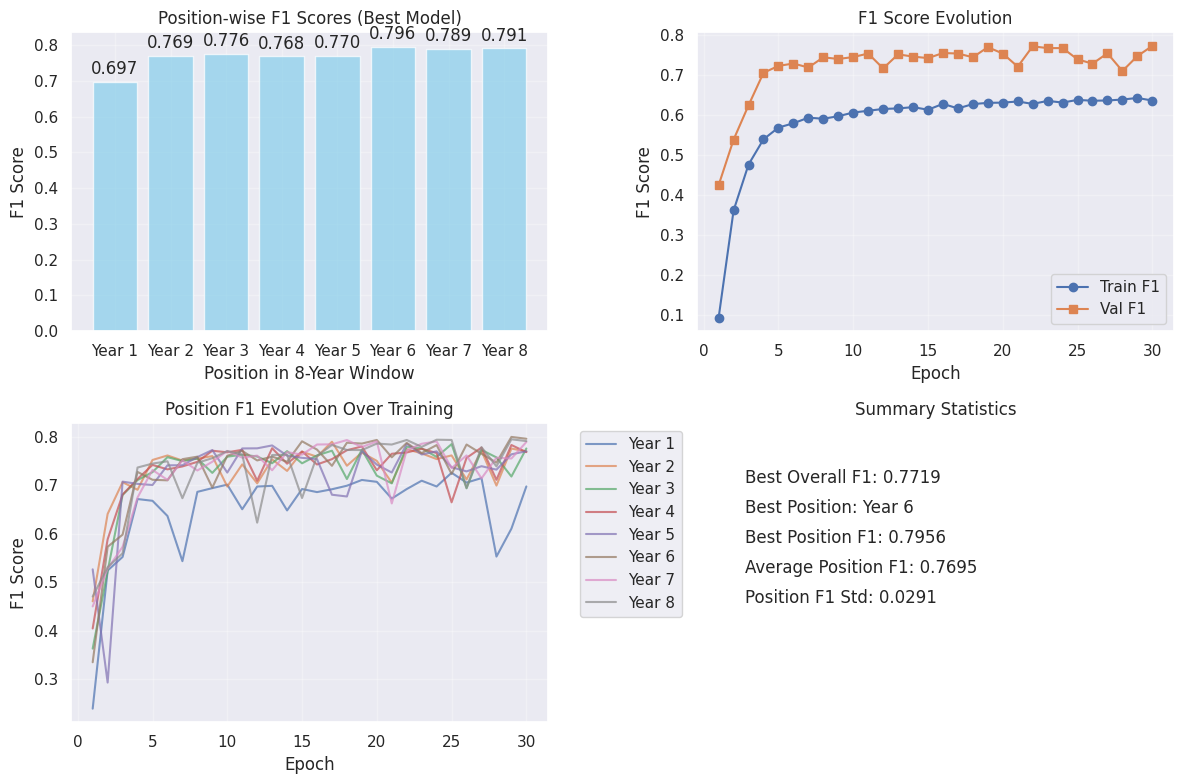


FINAL POSITION ANALYSIS SUMMARY
Year 1: F1=0.6973
Year 2: F1=0.7694
Year 3: F1=0.7756
Year 4: F1=0.7680
Year 5: F1=0.7699
Year 6: F1=0.7956 ⭐
Year 7: F1=0.7889
Year 8: F1=0.7908

Recommendation: Use Year 6 for optimal predictions
This gives +3.1% improvement over normal F1


In [24]:
#compute average f1 score for each step

# Add this visualization after training
import matplotlib.pyplot as plt

# Plot position analysis for the best model
plt.figure(figsize=(12, 8))

# Subplot 1: Position F1 scores for best model
plt.subplot(2, 2, 1)
plt.bar(range(1, 9), best_position_f1s, color='skyblue', alpha=0.7)
plt.title('Position-wise F1 Scores (Best Model)')
plt.xlabel('Position in 8-Year Window')
plt.ylabel('F1 Score')
plt.xticks(range(1, 9), [f'Year {i}' for i in range(1, 9)])
plt.grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(best_position_f1s):
    plt.text(i+1, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# Subplot 2: F1 evolution over training
plt.subplot(2, 2, 2)
epochs = range(1, len(train_f1s) + 1)
plt.plot(epochs, train_f1s, label='Train F1', marker='o')
plt.plot(epochs, val_f1s, label='Val F1', marker='s')
plt.title('F1 Score Evolution')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Position F1 evolution over epochs (optional - shows how positions change)
plt.subplot(2, 2, 3)
val_position_f1s_array = np.array(val_position_f1s)  # Shape: (epochs, positions)
for pos in range(8):
    plt.plot(epochs, val_position_f1s_array[:, pos], label=f'Year {pos+1}', alpha=0.7)
plt.title('Position F1 Evolution Over Training')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Subplot 4: Summary statistics
plt.subplot(2, 2, 4)
avg_f1 = np.mean(best_position_f1s)
std_f1 = np.std(best_position_f1s)
plt.text(0.1, 0.8, f'Best Overall F1: {best_val_f1:.4f}', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.7, f'Best Position: Year {best_position_idx+1}', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.6, f'Best Position F1: {best_position_f1s[best_position_idx]:.4f}', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.5, f'Average Position F1: {avg_f1:.4f}', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.4, f'Position F1 Std: {std_f1:.4f}', fontsize=12, transform=plt.gca().transAxes)
plt.title('Summary Statistics')
plt.axis('off')

plt.tight_layout()
plt.show()

# Print final summary
print(f"\n{'='*50}")
print("FINAL POSITION ANALYSIS SUMMARY")
print(f"{'='*50}")
for i, f1 in enumerate(best_position_f1s):
    marker = " ⭐" if i == best_position_idx else ""
    print(f"Year {i+1}: F1={f1:.4f}{marker}")

print(f"\nRecommendation: Use Year {best_position_idx+1} for optimal predictions")
print(f"This gives {((best_position_f1s[best_position_idx] - best_val_f1)/best_val_f1*100):+.1f}% improvement over normal F1")

## 5. Evaluation

ValueError: x and y must have same first dimension, but have shapes (30,) and (0,)

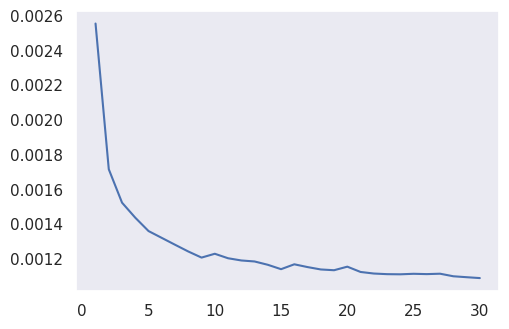

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(12, 8))

# Loss
plt.subplot(2, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs, train_accs, label='Train Acc')
plt.plot(epochs, val_accs, label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# F1 Score
plt.subplot(2, 2, 3)
plt.plot(epochs, train_f1s, label='Train F1')
plt.plot(epochs, val_f1s, label='Val F1')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.legend()

# Precision, Recall, Threshold
plt.subplot(2, 2, 4)
plt.plot(epochs, val_precisions, label='Val Precision')
plt.plot(epochs, val_recalls, label='Val Recall')
plt.plot(epochs, val_thresholds, label='Best Threshold')
plt.title('Precision, Recall & Threshold')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("\nConfusion Matrix:")
print(confusion_matrix(y_true_val, y_pred_val))
print("\nClassification Report:")
print(classification_report(y_true_val, y_pred_val , zero_division=0))

def plot_confusion_matrix(y_true, y_pred, labels=["No Disturbance", "Disturbance"], normalize=True, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, cbar=False)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_true_val, y_pred_val)


Confusion Matrix:


NameError: name 'y_true_val' is not defined